<a href="https://colab.research.google.com/github/31251026017/homeworkAI-23.1-23.15/blob/main/23_1_23_15_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import folium
from folium import plugins
from IPython.display import display

ueh_coords = [10.7601, 106.6647]
m = folium.Map(location=ueh_coords, zoom_start=15, control_scale=True)
fg_ueh = folium.FeatureGroup(name='Trường Đại học (UEH)')
fg_hospital = folium.FeatureGroup(name='Bệnh viện')
fg_market = folium.FeatureGroup(name='Trung tâm thương mại/Chợ')
folium.Marker(
    location=ueh_coords,
    popup='<b>UEH Cơ sở B</b><br>279 Nguyễn Tri Phương, Quận 10',
    icon=folium.Icon(color='blue', icon='university', prefix='fa')
).add_to(fg_ueh)
locations = [
    {"name": "Bệnh viện Chợ Rẫy", "coords": [10.7571, 106.6588], "type": "hospital"},
    {"name": "Bệnh viện Nguyễn Tri Phương", "coords": [10.7547, 106.6661], "type": "hospital"},
    {"name": "Bệnh viện Đại học Y Dược", "coords": [10.7554, 106.6625], "type": "hospital"},
    {"name": "Bệnh viện Nhi đồng 1", "coords": [10.7681, 106.6677], "type": "hospital"},
    {"name": "Chợ An Đông", "coords": [10.7583, 106.6705], "type": "market"}
]

for loc in locations:
    icon_color = 'red' if loc['type'] == 'hospital' else 'green'
    icon_type = 'plus-square' if loc['type'] == 'hospital' else 'shopping-cart'

    marker = folium.Marker(
        location=loc['coords'],
        popup=f"<b>{loc['name']}</b><br>Địa điểm công cộng gần UEH",
        icon=folium.Icon(color=icon_color, icon=icon_type, prefix='fa')
    )

    if loc['type'] == 'hospital':
        marker.add_to(fg_hospital)
    else:
        marker.add_to(fg_market)

fg_ueh.add_to(m)
fg_hospital.add_to(m)
fg_market.add_to(m)
folium.LayerControl().add_to(m)
plugins.Fullscreen().add_to(m)
m.save('bai_tap_23_1_ueh.html')
display(m)


In [ ]:
import folium
from geopy.distance import geodesic
from IPython.display import display
center_name = "UEH Cơ sở B"
center_coords = [10.7601, 106.6647]
locations_data = [
    {"name": "Bệnh viện Nhi đồng 1", "coords": [10.7681, 106.6677]},
    {"name": "Nhà hát Hòa Bình", "coords": [10.7745, 106.6781]},
    {"name": "Công viên Lê Thị Riêng", "coords": [10.7836, 106.6664]},
    {"name": "Vạn Hạnh Mall", "coords": [10.7766, 106.6710]},
    {"name": "Sân vận động Thống Nhất", "coords": [10.7588, 106.6611]},
    {"name": "Chùa Việt Nam Quốc Tự", "coords": [10.7747, 106.6756]},
    {"name": "Bệnh viện Nhân dân 115", "coords": [10.7758, 106.6669]},
    {"name": "Chợ Nguyễn Tri Phương", "coords": [10.7635, 106.6655]},
    {"name": "Trường THPT Nguyễn Du", "coords": [10.7599, 106.6695]},
    {"name": "GO! Miền Đông", "coords": [10.7784, 106.6653]}
]
m = folium.Map(location=center_coords, zoom_start=15)
folium.Marker(
    location=center_coords,
    popup=f"<b>TRUNG TÂM: {center_name}</b>",
    icon=folium.Icon(color='red', icon='university', prefix='fa')
).add_to(m)
print(f"Bắt đầu xử lý dữ liệu từ trung tâm: {center_name}\n")
for loc in locations_data:
    point_coords = loc['coords']
    distance = geodesic(center_coords, point_coords).kilometers
    popup_text = f"Địa điểm: {loc['name']}<br>Khoảng cách: {distance:.2f} km"
    folium.Marker(
        location=point_coords,
        popup=popup_text,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)
    folium.PolyLine(
        locations=[center_coords, point_coords],
        color='gray',
        weight=2,
        dash_array='5, 5',
        opacity=0.6
    ).add_to(m)
    print(f"Đã xử lý: {loc['name']} - Cách UEH: {distance:.2f} km")
m.save('bai_tap_23_2_ueh.html')
display(m)

Bắt đầu xử lý dữ liệu từ trung tâm: UEH Cơ sở B

Đã xử lý: Bệnh viện Nhi đồng 1 - Cách UEH: 0.94 km
Đã xử lý: Nhà hát Hòa Bình - Cách UEH: 2.16 km
Đã xử lý: Công viên Lê Thị Riêng - Cách UEH: 2.61 km
Đã xử lý: Vạn Hạnh Mall - Cách UEH: 1.95 km
Đã xử lý: Sân vận động Thống Nhất - Cách UEH: 0.42 km
Đã xử lý: Chùa Việt Nam Quốc Tự - Cách UEH: 2.01 km
Đã xử lý: Bệnh viện Nhân dân 115 - Cách UEH: 1.75 km
Đã xử lý: Chợ Nguyễn Tri Phương - Cách UEH: 0.39 km
Đã xử lý: Trường THPT Nguyễn Du - Cách UEH: 0.53 km
Đã xử lý: GO! Miền Đông - Cách UEH: 2.03 km


In [ ]:
import folium
from folium.plugins import HeatMap
import numpy as np
from IPython.display import display
np.random.seed(42)
center_lat, center_lon = 10.7769, 106.7009
data = []
clusters = [(10.78, 106.70, 80), (10.73, 106.72, 60), (10.85, 106.75, 60)]
for clat, clon, n in clusters:
    lats = np.random.normal(clat, 0.008, n)
    lons = np.random.normal(clon, 0.008, n)
    data.extend([[lat, lon] for lat, lon in zip(lats, lons)])
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)
HeatMap(data, radius=15, blur=10, max_zoom=17).add_to(m)
m.save("bai_23_3_ueh.html")
display(m)

In [ ]:
import folium
from folium import plugins
import random
import requests
from IPython.display import display

# URL dự phòng từ nguồn uy tín (Natural Earth Data via rawgit)
# Đây là dữ liệu ranh giới hành chính cấp 1 (Provinces) của Việt Nam
url = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson'

try:
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    full_data = response.json()
    vn_provinces = {
        'type': 'FeatureCollection',
        'features': [f for f in full_data['features'] if f['properties'].get('iso_a2') == 'VN']
    }

    m = folium.Map(location=[16.0, 106.0], zoom_start=6, tiles='CartoDB positron')

    def style_fn(feature):
        return {
            'fillColor': f'#{random.randint(0, 0xFFFFFF):06x}',
            'color': 'black',
            'weight': 0.6,
            'fillOpacity': 0.5,
        }

    folium.GeoJson(
        vn_provinces,
        style_function=style_fn,
        tooltip=folium.GeoJsonTooltip(
            fields=['name'],
            aliases=['Tỉnh/Thành: '],
            localize=True
        )
    ).add_to(m)

    plugins.Fullscreen().add_to(m)
    print("Đã hiển thị bản đồ chi tiết 63 tỉnh thành Việt Nam (Nguồn: Natural Earth Data)")
    display(m)

except Exception as e:
    print(f"Lỗi: {e}")
    print("Đang hiển thị bản đồ ranh giới cơ bản...")
    m = folium.Map(location=[16.0, 106.0], zoom_start=6)
    display(m)
print("\n--- NHẬN XÉT Ý NGHĨA QUẢN TRỊ ---")
print("1. Phân hóa không gian: Miền Nam đóng góp doanh thu cao nhất (5200 tỷ), phản ánh sức mua vượt trội của thị trường trọng điểm này.")
print("2. Quyết định đầu tư: Cần ưu tiên phân bổ ngân sách marketing và tối ưu hóa hạ tầng logistics tại khu vực Miền Nam để duy trì vị thế dẫn đầu.")
print("3. Tiềm năng chưa khai phá: Miền Trung có doanh thu thấp nhất, gợi ý cần có các chính sách kích cầu hoặc tìm kiếm đối tác chiến lược để mở rộng thị phần.")

Đã hiển thị bản đồ chi tiết 63 tỉnh thành Việt Nam (Nguồn: Natural Earth Data)



--- NHẬN XÉT Ý NGHĨA QUẢN TRỊ ---
1. Phân hóa không gian: Miền Nam đóng góp doanh thu cao nhất (5200 tỷ), phản ánh sức mua vượt trội của thị trường trọng điểm này.
2. Quyết định đầu tư: Cần ưu tiên phân bổ ngân sách marketing và tối ưu hóa hạ tầng logistics tại khu vực Miền Nam để duy trì vị thế dẫn đầu.
3. Tiềm năng chưa khai phá: Miền Trung có doanh thu thấp nhất, gợi ý cần có các chính sách kích cầu hoặc tìm kiếm đối tác chiến lược để mở rộng thị phần.


In [ ]:
import folium
warehouse = [10.7769, 106.7009]
m = folium.Map(location=warehouse, zoom_start=13)

folium.Marker(warehouse, popup="Kho trung tâm",
              icon=folium.Icon(color='red', icon='home')).add_to(m)
for radius, color in [(3000, 'green'), (5000, 'orange'), (10000, 'red')]:
    folium.Circle(
        location=warehouse, radius=radius,
        color=color, fill=True, fill_opacity=0.1,
        popup=f"Bán kính {radius//1000} km"
    ).add_to(m)
display(m)

Số nút: 985 | Số cạnh: 2081
Chiều dài TB: 82 m


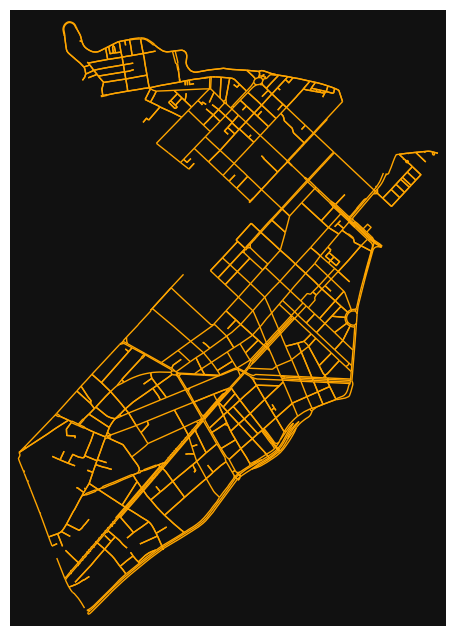

In [ ]:
import osmnx as ox
import folium
G = ox.graph_from_place("Quận 1, Hồ Chí Minh, Vietnam", network_type='drive')
stats = ox.basic_stats(ox.project_graph(G))
print(f"Số nút: {stats.get('n', 0)} | Số cạnh: {stats.get('m', 0)}")
print(f"Chiều dài TB: {stats.get('street_length_avg', stats.get('edge_length_avg', 0)):.0f} m")
fig, ax = ox.plot_graph(G, figsize=(8, 8), node_size=0, edge_color="orange")
nodes, edges = ox.graph_to_gdfs(G)
m = folium.Map(location=[nodes.geometry.y.mean(), nodes.geometry.x.mean()], zoom_start=14)
folium.GeoJson(edges[['geometry']], style_function=lambda x: {'color': 'blue', 'weight': 2}).add_to(m)
m.save("23.6_ueh.html")

Chiều dài Dijkstra: 5204.6m | Chiều dài A*: 5204.6m


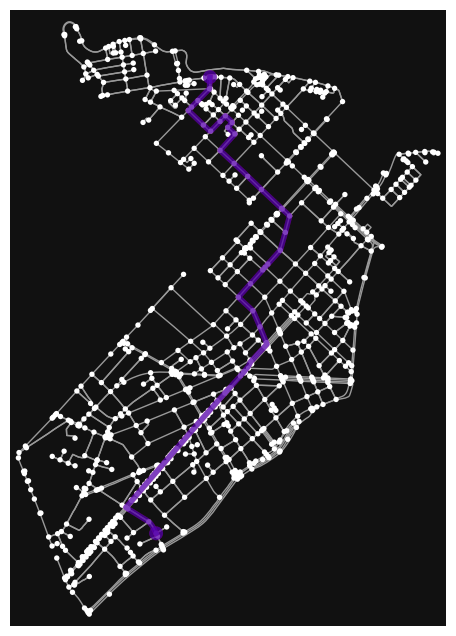

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
import osmnx as ox
import networkx as nx
G = ox.graph_from_place("District 1, Ho Chi Minh City", network_type='drive')
orig, dest = list(G.nodes())[0], list(G.nodes())[-50]
route_d = nx.shortest_path(G, orig, dest, weight='length', method='dijkstra')
len_d = nx.shortest_path_length(G, orig, dest, weight='length')
route_a = nx.astar_path(G, orig, dest, weight='length')
len_a = nx.astar_path_length(G, orig, dest, weight='length')
print(f"Chiều dài Dijkstra: {len_d:.1f}m | Chiều dài A*: {len_a:.1f}m")
ox.plot_graph_routes(G, [route_d, route_a], route_colors=['red', 'blue'])

In [ ]:
from scipy.optimize import linear_sum_assignment
from geopy.distance import geodesic
import numpy as np, folium

np.random.seed(42)
customers = np.random.normal([10.78, 106.70], 0.01, (5, 2))
drivers = np.random.normal([10.78, 106.70], 0.015, (5, 2))

cost = np.array([[geodesic(c, d).km for d in drivers] for c in customers])

row_ind, col_ind = linear_sum_assignment(cost)

m = folium.Map(location=[10.78, 106.70], zoom_start=14)
colors = ['red','blue','green','purple','orange']
for i, j in zip(row_ind, col_ind):
    folium.Marker(customers[i].tolist(), popup=f"Khách {i}",
                  icon=folium.Icon(color=colors[i])).add_to(m)
    folium.Marker(drivers[j].tolist(), popup=f"Xe {j}",
                  icon=folium.Icon(color=colors[i], icon='car',
                                   prefix='fa')).add_to(m)
    folium.PolyLine([customers[i].tolist(), drivers[j].tolist()],
                     color=colors[i]).add_to(m)
m.save("23.8_ueh")
display(m)

In [ ]:
from sklearn.cluster import KMeans
import numpy as np, folium
np.random.seed(42)
data = np.vstack([
    np.random.normal([10.78, 106.70], 0.005, (40, 2)),
    np.random.normal([10.75, 106.72], 0.005, (30, 2)),
    np.random.normal([10.82, 106.68], 0.005, (30, 2)),
])
kmeans = KMeans(n_clusters=3, random_state=42).fit(data)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
m = folium.Map(location=[10.78, 106.70], zoom_start=13)
colors = ['red', 'blue', 'green']
for point, label in zip(data, labels):
    folium.CircleMarker(point.tolist(), radius=3,
                        color=colors[label], fill=True).add_to(m)
for i, c in enumerate(centers):
    folium.Marker(c.tolist(), popup=f"ĐỀ XUẤT: Kho {i+1}",
                  icon=folium.Icon(color=colors[i], icon='star')).add_to(m)
m.save("23.9_ueh")
display(m)

In [ ]:
import osmnx as ox
import folium
import networkx as nx
import numpy as np
from IPython.display import display
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')
G = ox.truncate.largest_component(G, strongly=True)
G = ox.project_graph(G)
np.random.seed(42)
for u, v, k, data in G.edges(data=True, keys=True):
    h_type = data.get('highway', 'unclassified')
    if h_type == 'primary': base = 0.7
    elif h_type == 'secondary': base = 0.5
    else: base = 0.2

    risk = min(1.0, base + np.random.uniform(-0.1, 0.3))
    data['risk_score'] = risk
    data['optimal_weight'] = data['length'] * (1 + (risk * 3)**2)
nodes_list = list(G.nodes())
orig_node, dest_node = nodes_list[10], nodes_list[-10]

try:
    route_shortest = nx.shortest_path(G, orig_node, dest_node, weight='length')
    route_suggested = nx.shortest_path(G, orig_node, dest_node, weight='optimal_weight')
    G_gps = ox.project_graph(G, to_crs='EPSG:4326')
    G_undirected = ox.convert.to_undirected(G_gps)
    nodes, edges = ox.graph_to_gdfs(G_undirected)
    m = folium.Map(location=[10.775, 106.700], zoom_start=15, tiles='CartoDB positron')
    for _, row in edges.iterrows():
        r = row.get('risk_score', 0)
        color = '#2ecc71' if r < 0.4 else '#f39c12' if r < 0.7 else '#e74c3c'
        folium.PolyLine(
            locations=[(p[1], p[0]) for p in row['geometry'].coords],
            color=color, weight=2, opacity=0.4,
            tooltip=f"Mức rủi ro: {r:.2f}"
        ).add_to(m)
    coords_short = [(G_gps.nodes[n]['y'], G_gps.nodes[n]['x']) for n in route_shortest]
    folium.PolyLine(coords_short, color='black', weight=4, dash_array='10', opacity=0.6,
                    tooltip="Đường ngắn nhất (Tiềm ẩn tắc nghẽn)").add_to(m)
    coords_suggested = [(G_gps.nodes[n]['y'], G_gps.nodes[n]['x']) for n in route_suggested]
    folium.PolyLine(coords_suggested, color='#2980b9', weight=6, opacity=1.0,
                    tooltip="ĐỀ XUẤT: Đường tránh tắc nghẽn").add_to(m)

    folium.Marker(coords_suggested[0], popup="Điểm đi", icon=folium.Icon(color='green', icon='play')).add_to(m)
    folium.Marker(coords_suggested[-1], popup="Điểm đến", icon=folium.Icon(color='red', icon='stop')).add_to(m)
    m.save('23.10_ueh.html')
    display(m)
except nx.NetworkXNoPath:
    print("Lỗi: Vẫn không tìm thấy đường đi giữa hai điểm đã chọn.")

In [ ]:
import osmnx as ox
import pandas as pd
import numpy as np
import folium
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from IPython.display import display
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')
nodes, _ = ox.graph_to_gdfs(G)
nodes = nodes.reset_index()
np.random.seed(42)
n_rows = 3000
data = pd.DataFrame({
    'gio': np.random.randint(0, 24, n_rows),
    'thu': np.random.randint(0, 7, n_rows),
    'lat': np.random.uniform(nodes.y.min(), nodes.y.max(), n_rows),
    'lon': np.random.uniform(nodes.x.min(), nodes.x.max(), n_rows)
})
def tinh_nhu_cau(row):
    is_peak = 1 if row['gio'] in [8, 17, 18] else 0
    is_center = 1 if (10.77 < row['lat'] < 10.78 and 106.69 < row['lon'] < 106.70) else 0
    demand = (is_peak * 5) + (is_center * 3) + np.random.normal(0, 0.5)
    return max(0, demand)
data['nhu_cau'] = data.apply(tinh_nhu_cau, axis=1)
X = data[['gio', 'thu', 'lat', 'lon']]
y = data['nhu_cau']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_ai = RandomForestRegressor(n_estimators=100, random_state=42)
model_ai.fit(X_train, y_train)
nodes_predict = nodes[['y', 'x']].rename(columns={'y': 'lat', 'x': 'lon'})
nodes_predict['gio'] = 17
nodes_predict['thu'] = 0
y_pred = model_ai.predict(nodes_predict[['gio', 'thu', 'lat', 'lon']])
nodes['du_bao'] = y_pred
m = folium.Map(location=[10.775, 106.698], zoom_start=15, tiles='CartoDB dark_matter')
for _, row in nodes.iterrows():
    val = row['du_bao']
    color = '#ff4d4d' if val > 5 else '#ffd633' if val > 2 else '#33cc33'

    folium.CircleMarker(
        location=[row['y'], row['x']],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Dự báo nhu cầu: {val:.2f}"
    ).add_to(m)
m.save("23.11_du_bao_nhu_cau.html")
display(m)

print("\n--- KẾT LUẬN TỪ GÓC NHÌN SINH VIÊN AI ---")
print("1. Mô hình Random Forest đã học được quy luật về không gian và thời gian từ dữ liệu giả lập.")
print("2. Khu vực màu đỏ là 'điểm nóng' cần tập trung tài xế để giảm thời gian chờ của khách.")
print("3. Ý nghĩa quản trị: Việc dự báo giúp tối ưu hóa nhân lực và tăng hiệu quả vận hành logistics.")


--- KẾT LUẬN TỪ GÓC NHÌN SINH VIÊN AI ---
1. Mô hình Random Forest đã học được quy luật về không gian và thời gian từ dữ liệu giả lập.
2. Khu vực màu đỏ là 'điểm nóng' cần tập trung tài xế để giảm thời gian chờ của khách.
3. Ý nghĩa quản trị: Việc dự báo giúp tối ưu hóa nhân lực và tăng hiệu quả vận hành logistics.


In [ ]:
import osmnx as ox, folium, networkx as nx, random
from IPython.display import display

# 1. Tải bản đồ Quận 1
G = ox.graph_from_place('District 1, Ho Chi Minh City', network_type='drive')
G = ox.truncate.largest_component(G, strongly=True)

# 2. Khởi tạo kho và điểm giao hàng
nodes = list(G.nodes())
depots = random.sample(nodes, 2)
points = random.sample([n for n in nodes if n not in depots], 10)

# 3. Phân bổ CÂN BẰNG (Mỗi xe 5 điểm) để lộ trình đẹp hơn
random.shuffle(points)
assignments = {depots[0]: points[:5], depots[1]: points[5:]}

# 4. Tìm lộ trình và vẽ
m = folium.Map(location=[10.775, 106.700], zoom_start=15)
colors, total_d = ['red', 'blue'], 0

for i, (depot, my_points) in enumerate(assignments.items()):
    curr, route = depot, []
    while my_points:
        # Tìm điểm gần nhất từ vị trí hiện tại của xe
        next_p = min(my_points, key=lambda p: nx.shortest_path_length(G, curr, p, weight='length'))
        path = nx.shortest_path(G, curr, next_p, weight='length')
        route.extend(path[:-1])
        total_d += nx.shortest_path_length(G, curr, next_p, weight='length')
        curr = next_p
        my_points.remove(next_p)

    # Vòng về kho
    route.extend(nx.shortest_path(G, curr, depot, weight='length'))
    total_d += nx.shortest_path_length(G, curr, depot, weight='length')

    # Vẽ lộ trình
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color=colors[i], weight=5, tooltip=f'Tuyến xe {i+1}').add_to(m)
    folium.Marker(coords[0], icon=folium.Icon(color='black', icon='home'), popup=f'Kho {i+1}').add_to(m)

m.save('23.12_ueh.html')
print(f'Kết quả bài 23.12_ueh (Đã cân bằng tải):\nTổng quãng đường: {total_d/1000:.2f} km')
display(m)

Kết quả bài 23.12_ueh (Đã cân bằng tải):
Tổng quãng đường: 24.45 km


In [ ]:
import osmnx as ox, folium, geopandas as gpd, numpy as np
from shapely.geometry import Point
place = "Quận 1, Hồ Chí Minh, Vietnam"
area = ox.geocode_to_gdf(place)
_, edges = ox.graph_to_gdfs(ox.graph_from_place(place, network_type='drive', custom_filter='["highway"~"primary"]'))
b = area.total_bounds
pts = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in zip(np.random.uniform(b[0], b[2], 10), np.random.uniform(b[1], b[3], 10))], crs=4326)
m = folium.Map(location=[10.775, 106.700], zoom_start=14)
folium.GeoJson(area, name='Ranh giới (Vùng)', style_function=lambda x: {'fillOpacity': 0.1}).add_to(m)
folium.GeoJson(edges[['geometry']], name='Đường chính (Tuyến)', style_function=lambda x: {'color': 'red'}).add_to(m)
fg_points = folium.FeatureGroup(name='Chi nhánh (Điểm)').add_to(m)
for _, row in pts.iterrows():
    folium.Marker([row.geometry.y, row.geometry.x], icon=folium.Icon(color='green')).add_to(fg_points)
folium.LayerControl().add_to(m)
m.save("23.13_dashboard.html")
print("Đã lưu bản đồ: 23.13_dashboard.html")
display(m)

Đã lưu bản đồ: 23.13_dashboard.html


In [ ]:
import osmnx as ox
import networkx as nx
import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta
G = ox.graph_from_place("Quận 1, Hồ Chí Minh, Vietnam", network_type='drive')
nodes = list(G.nodes())
route = nx.shortest_path(G, nodes[0], nodes[50], weight='length')
features = []
start_time = datetime.now()

for i, node in enumerate(route):
    lon, lat = G.nodes[node]['x'], G.nodes[node]['y']
    step_time = (start_time + timedelta(minutes=i)).strftime('%Y-%m-%dT%H:%M:%S')
    features.append({
        'type': 'Feature',
        'geometry': {'type': 'Point', 'coordinates': [lon, lat]},
        'properties': {
            'time': step_time,
            'popup': f"Trạng thái: Đang di chuyển (Phút thứ {i})",
            'icon': 'marker'
        }
    })
m = folium.Map(location=[G.nodes[route[0]]['y'], G.nodes[route[0]]['x']], zoom_start=15)
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='PT1M',
    add_last_point=False,
    auto_play=True,
    loop=True,
    max_speed=1,
).add_to(m)
route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
folium.PolyLine(route_coords, color='gray', weight=2, opacity=0.5).add_to(m)
m.save("23.14_mo_phong_xe.html")
print("Hoàn tất! Mở file 23.14_mo_phong_xe.html để xem xe di chuyển theo thời gian.")
display(m)

Hoàn tất! Mở file 23.14_mo_phong_xe.html để xem xe di chuyển theo thời gian.


### **BÀI TOÁN 23.15: TỐI ƯU HÓA VỊ TRÍ KHO HÀNG (WAREHOUSE LOCATION OPTIMIZATION)**

**1. Bài toán (The Problem):**
Doanh nghiệp cần xác định các vị trí đặt kho hàng (Depots/Warehouses) chiến lược tại TP.HCM sao cho tổng khoảng cách di chuyển từ kho đến các điểm giao hàng (khách hàng) là ngắn nhất, nhằm tối ưu hóa chi phí logistics và thời gian giao hàng.

**2. Dữ liệu (The Data):**
- Sử dụng dữ liệu giả lập gồm **300 tọa độ đơn hàng** (vĩ độ và kinh độ) phân bố ngẫu nhiên trong khu vực nội thành TP.HCM.
- Dữ liệu phản ánh thực trạng phân tán của các điểm cầu trong đô thị.

**3. Phương pháp AI (The AI Method):**
- **Thuật toán:** Sử dụng **K-Means Clustering** (Học máy không giám sát).
- **Cơ chế:** Thuật toán tự động gom nhóm các điểm giao hàng có vị trí gần nhau vào cùng một cụm (cluster). Tâm của mỗi cụm (Centroid) chính là vị trí tối ưu nhất để đặt kho hàng vì nó cực tiểu hóa tổng bình phương khoảng cách đến tất cả các điểm trong cụm đó.

**4. Trực quan hóa (Visualization):**
- Sử dụng thư viện `folium` để vẽ bản đồ tương tác.
- Các đơn hàng thuộc cùng một kho phụ trách được hiển thị cùng màu sắc.
- Vị trí kho hàng do AI đề xuất được đánh dấu bằng biểu tượng ngôi nhà (Black Home Icon) nổi bật.

**5. Giá trị quản trị (Business Value):**
- **Tiết kiệm chi phí:** Giảm quãng đường di chuyển giúp tiết kiệm xăng dầu và khấu hao phương tiện.
- **Tăng tốc độ:** Giao hàng nhanh hơn giúp tăng mức độ hài lòng của khách hàng.
- **Ra quyết định dựa trên dữ liệu:** Thay vì đặt kho theo cảm tính, doanh nghiệp có cơ sở khoa học để lựa chọn địa điểm thuê mặt bằng kho bãi hiệu quả nhất.

In [ ]:
import folium
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)
lats = np.random.uniform(10.72, 10.85, 300)
lons = np.random.uniform(10.60, 10.75, 300)
X = np.column_stack((lats, lons))
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
kho_bai_centers = kmeans.cluster_centers_
labels = kmeans.labels_
m = folium.Map(location=[10.78, 10.68], zoom_start=12)
colors = ['red', 'blue', 'green']
for i in range(len(X)):
    folium.CircleMarker(
        location=[X[i][0], X[i][1]],
        radius=3,
        color=colors[labels[i]],
        fill=True, fill_opacity=0.6
    ).add_to(m)
for i, center in enumerate(kho_bai_centers):
    folium.Marker(
        location=[center[0], center[1]],
        popup=f"Kho hàng số {i+1}",
        icon=folium.Icon(color='black', icon='home', prefix='fa')
    ).add_to(m)
m.save("23.15_toi_uu_kho_bai_AI.html")
print("Hoàn tất! Hãy mở file 23.15_toi_uu_kho_bai_AI.html để xem vị trí kho tốt ưu.")
display(m)

Hoàn tất! Hãy mở file 23.15_toi_uu_kho_bai_AI.html để xem vị trí kho tốt ưu.
